# UC4 — Brute Force Detection: XGBoost Training & Evaluation

**Goal:** Train a supervised XGBoost binary classifier on CICIDS2017 network
flow data to distinguish benign traffic from brute-force attacks
(FTP-Patator, SSH-Patator).

### Relationship to UC2

UC2 and UC4 share the same feature set and the same model type (XGBoost), but
target mechanistically different attack families:

| | UC2 (DDoS) | UC4 (Brute Force) |
|---|---|---|
| **Attack** | Volumetric flooding | Credential-based repeated auth |
| **Source** | Friday afternoon | Tuesday |
| **Key features** | High byte/packet rates, sustained flows | Short connections, RST flags, targeted ports |
| **Score separation** | Bimodal — fixed 0.5 threshold | Bimodal — fixed 0.5 threshold |

In the Detection microservice, both models run on the same flow feature
vector — one flow in, two independent predictions out.

### Inputs (from the UC4 data-prep notebook)

| File | Description |
|------|-------------|
| `train.csv` | Monday benign + first 70% of Tuesday |
| `test.csv` | Last 30% of Tuesday (temporal holdout) |

Feature columns are loaded from `flow_feature_cols.json` (feature parity with UC2).

### Threshold policy (same as UC2 — fixed 0.5)

Both models' scores separate cleanly into two spikes near 0 (benign) and 1
(attack), so a **fixed 0.5** cutoff lands in the empty valley between them and
tuning yields nothing. UC4 uses `threshold_source = 'fixed_0.5'`, identical to
UC2. A validation PR sweep is computed as a **sanity check only** — it confirms
0.5 sits on a flat region of the F1 curve — and is never used to select the
operating point. The bimodal score separation is shown explicitly (Section 13)
as the empirical justification, mirroring UC2's evidence.

### Pipeline

1. Load prepared CSVs and feature list
2. Sanity checks
3. **Stratified validation slice** carved from the training set (mirrors UC2)
4. Train XGBoost with class-imbalance handling (`scale_pos_weight`), early
   stopping on the validation slice
5. **Fixed 0.5 threshold**; validation PR sweep retained as a sanity check
6. Evaluation on test at the frozen threshold: confusion matrix, report, AUCs
7. Feature importance, FP/FN profiling
8. Cross-UC evaluation
9. Model persistence (joblib artifact bundle)
10. Inference helper for the Detection microservice

### Design Constraints

- **No circular labeling** — labels from CIC ground truth annotations.
- **Temporal split** — train/test boundary preserves time ordering.
- **Threshold fixed at 0.5** — not tuned on test or validation (no test-set fitting).
- **Feature parity with UC2** — identical feature columns.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)

import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print(f'XGBoost version: {xgb.__version__}')
print('Libraries loaded.')

XGBoost version: 3.2.0
Libraries loaded.


## 1. Configuration

In [2]:
# ── Paths ──
DATA_DIR     = './data/'
FEAT_DIR     = './data/'
MODEL_DIR    = './models/'
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_CSV    = os.path.join(DATA_DIR, 'train.csv')
TEST_CSV     = os.path.join(DATA_DIR, 'test.csv')
META_JSON    = os.path.join(DATA_DIR, 'metadata.json')
FEAT_JSON    = os.path.join(FEAT_DIR, 'flow_feature_cols.json')
ARTIFACT_OUT = os.path.join(MODEL_DIR, 'brute_force_xgboost.pkl')

# UC2 model for cross-evaluation
UC2_ARTIFACT = os.path.join('../ddos/models/', 'ddos_xgboost.pkl')

# ── Random seed ──
SEED = 42

print(f'Train CSV:       {TRAIN_CSV}')
print(f'Test CSV:        {TEST_CSV}')
print(f'Feature list:    {FEAT_JSON}')
print(f'Artifact output: {ARTIFACT_OUT}')

Train CSV:       ./data/train.csv
Test CSV:        ./data/test.csv
Feature list:    ./data/flow_feature_cols.json
Artifact output: ./models/brute_force_xgboost.pkl


## 2. Load Prepared Data

In [3]:
with open(FEAT_JSON) as f:
    feature_cols = json.load(f)

df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print(f'Feature columns: {len(feature_cols)}')
print(f'Train: {len(df_train):>10,} rows')
print(f'Test:  {len(df_test):>10,} rows')

# Verify all feature columns exist
for c in feature_cols:
    assert c in df_train.columns, f'Missing in train: {c}'
    assert c in df_test.columns,  f'Missing in test: {c}'
print('\nAll feature columns present in both splits.')

# ── Leakage guard: ports must NOT be features ──
# flow_feature_cols.json is shared with UC2. Destination Port encodes a fixed
# victim target in the CICIDS2017 lab campaigns rather than a generalizable
# signature, and Source Port is ephemeral; both are excluded. For UC4 this is
# slightly conservative — dst port 21/22 is genuinely diagnostic of FTP/SSH
# brute force in the real world — but a single shared feature set keeps UC2 and
# UC4 consistent and avoids per-UC leakage carve-outs. Fail loud if an old JSON
# restores the port columns.
_leaky = [c for c in feature_cols
          if c.strip().lower().replace('_', ' ') in ('destination port', 'source port')]
assert not _leaky, f'Port column(s) must not be in feature_cols (leakage): {_leaky}'
assert len(feature_cols) == 43, f'Expected 43 features after dropping ports, got {len(feature_cols)}'
print(f'Leakage guard passed: no port columns; {len(feature_cols)} features.')

Feature columns: 43
Train:    841,133 rows
Test:     134,694 rows

All feature columns present in both splits.
Leakage guard passed: no port columns; 43 features.


## 3. Sanity Checks

In [4]:
for name, df in [('Train', df_train), ('Test', df_test)]:
    n = len(df)
    n_atk = (df['label'] == 1).sum()
    n_ben = (df['label'] == 0).sum()
    feat = df[feature_cols]
    n_nan = feat.isna().sum().sum()
    n_inf = np.isinf(feat.select_dtypes(include=np.number)).sum().sum()

    print(f'── {name} ──')
    print(f'  Rows:    {n:>10,}')
    print(f'  Benign:  {n_ben:>10,}  ({100 * n_ben / n:.2f}%)')
    print(f'  Attack:  {n_atk:>10,}  ({100 * n_atk / n:.2f}%)')
    print(f'  NaN: {n_nan:,}  Inf: {n_inf:,}')
    if n_atk > 0:
        print(f'  Imbalance ratio: 1:{n_ben // n_atk}')
    print()

assert df_train[feature_cols].isna().sum().sum() == 0, 'NaN in train features!'
assert df_test[feature_cols].isna().sum().sum() == 0, 'NaN in test features!'
print('No NaN/Inf in features.')

── Train ──
  Rows:       841,133
  Benign:     830,102  (98.69%)
  Attack:      11,031  (1.31%)
  NaN: 0  Inf: 0
  Imbalance ratio: 1:75

── Test ──
  Rows:       134,694
  Benign:     131,890  (97.92%)
  Attack:       2,804  (2.08%)
  NaN: 0  Inf: 0
  Imbalance ratio: 1:47

No NaN/Inf in features.


## 4. Prepare Feature Matrices & Stratified Validation Slice

**Why stratified rather than positional-by-row-order** (this matches UC2's
methodology exactly):

`train.csv` is class-clustered — Monday benign first, then the first 70% of
Tuesday (where the attacks live). A positional last-15% slice would therefore
be heavily attack-enriched, giving the wrong class prior for both early-stopping
logloss and threshold calibration. Stratifying on `label` makes the validation
slice mirror the training set's true ~1.3% positive rate, giving a clean
early-stopping signal at the prior the model will see in production.

The temporal no-leakage guarantee is provided by the train/test boundary itself
(set in the data-prep notebook); the within-train val split does not need to be
temporal.

In [5]:
val_frac = 0.15

df_tr, df_val = train_test_split(
    df_train,
    test_size=val_frac,
    stratify=df_train['label'],
    random_state=SEED,
)
df_tr  = df_tr.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

X_tr,   y_tr   = df_tr[feature_cols].values,   df_tr['label'].values
X_val,  y_val  = df_val[feature_cols].values,  df_val['label'].values
X_test, y_test = df_test[feature_cols].values, df_test['label'].values

# Standardize (fit on train fold only — val and test are transformed)
scaler = StandardScaler()
X_tr_scaled   = scaler.fit_transform(X_tr)
X_val_scaled  = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Train fold:  {X_tr_scaled.shape}   pos={y_tr.sum():>8,}   '
      f'neg={(y_tr==0).sum():>8,}   pos_rate={y_tr.mean():.4f}')
print(f'Validation:  {X_val_scaled.shape}  pos={y_val.sum():>8,}   '
      f'neg={(y_val==0).sum():>8,}   pos_rate={y_val.mean():.4f}')
print(f'Test:        {X_test_scaled.shape} pos={y_test.sum():>8,}   '
      f'neg={(y_test==0).sum():>8,}   pos_rate={y_test.mean():.4f}')

Train fold:  (714963, 43)   pos=   9,376   neg= 705,587   pos_rate=0.0131
Validation:  (126170, 43)  pos=   1,655   neg= 124,515   pos_rate=0.0131
Test:        (134694, 43) pos=   2,804   neg= 131,890   pos_rate=0.0208


## 5. Train XGBoost

`scale_pos_weight` compensates for class imbalance (same approach as UC2),
computed as the benign:attack ratio in the **train fold** (not the full training
set, since the validation slice is held out). Early stopping is monitored on the
validation slice — the test set is never observed during training.

In [6]:
n_benign = (y_tr == 0).sum()
n_attack = (y_tr == 1).sum()
spw = n_benign / max(n_attack, 1)

print(f'scale_pos_weight: {spw:.2f}  (train-fold benign: {n_benign:,}, attack: {n_attack:,})')

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='logloss',
    early_stopping_rounds=20,
)

# eval_set: train fold (validation_0) + stratified validation slice (validation_1).
# Early stopping monitors the LAST entry, i.e. the validation slice — NOT the test set.
model.fit(
    X_tr_scaled, y_tr,
    eval_set=[(X_tr_scaled, y_tr), (X_val_scaled, y_val)],
    verbose=50,
)

print(f'\nTraining complete.  Best iteration: {model.best_iteration}')

scale_pos_weight: 75.25  (train-fold benign: 705,587, attack: 9,376)


[0]	validation_0-logloss:0.60797	validation_1-logloss:0.60783


[50]	validation_0-logloss:0.00535	validation_1-logloss:0.00545


[100]	validation_0-logloss:0.00024	validation_1-logloss:0.00030


[150]	validation_0-logloss:0.00008	validation_1-logloss:0.00016


[200]	validation_0-logloss:0.00007	validation_1-logloss:0.00015


[241]	validation_0-logloss:0.00007	validation_1-logloss:0.00015



Training complete.  Best iteration: 221


## 6. Training Curves

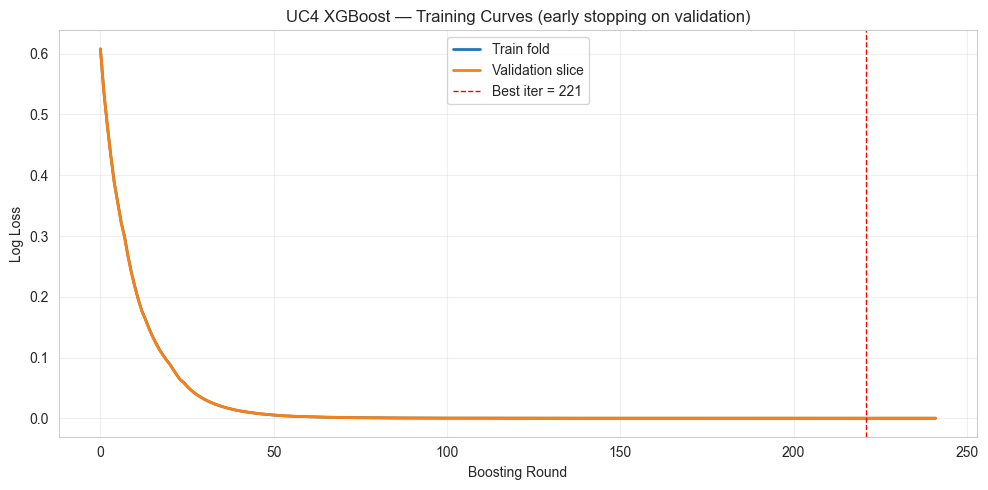

Final train-fold loss:  0.000066
Final validation loss:  0.000146


In [7]:
results = model.evals_result()
train_loss = results['validation_0']['logloss']
val_loss   = results['validation_1']['logloss']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_loss, label='Train fold', linewidth=2)
ax.plot(val_loss, label='Validation slice', linewidth=2)
ax.axvline(model.best_iteration, color='red', linestyle='--', linewidth=1,
           label=f'Best iter = {model.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('UC4 XGBoost — Training Curves (early stopping on validation)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final train-fold loss:  {train_loss[-1]:.6f}')
print(f'Final validation loss:  {val_loss[-1]:.6f}')

## 7. Threshold Policy and Validation Sanity Check

The probability threshold is **fixed at 0.5** — the standard cutoff for a binary
classifier, identical to UC2. We do not tune it on the test set (circular) nor on
the validation slice (unnecessary: the classes separate cleanly into two spikes
near 0 and 1, so 0.5 sits in the empty valley between them).

The validation PR curve below is a **sanity check only**: it confirms 0.5 lands on
a flat region of the F1 curve and lets us inspect class separation on data the
model never trained on. It does not select the operating point.

In [8]:
val_proba = model.predict_proba(X_val_scaled)[:, 1]

# ── Threshold policy: fixed at 0.5 (same as UC2) ──
# At this separation level F1 is flat across thresholds; tuning yields no
# meaningful gain and risks looking like test-set fitting.
threshold = 0.5
threshold_source = 'fixed_0.5'

# ── Validation PR curve — sanity check only ──
val_p, val_r, val_thr = precision_recall_curve(y_val, val_proba)
val_f1 = 2 * val_p[:-1] * val_r[:-1] / (val_p[:-1] + val_r[:-1] + 1e-10)
val_ap = average_precision_score(y_val, val_proba)

# F1 at the fixed 0.5 cutoff, and the max F1 anywhere (reference only)
val_05_idx   = int(np.argmin(np.abs(val_thr - 0.5)))
val_f1_at_05 = float(val_f1[val_05_idx])
val_best_f1  = float(val_f1.max())   # reference only, NOT used for selection

val_pred_05 = (val_proba >= threshold).astype(int)
val_fpr_05  = ((y_val == 0) & (val_pred_05 == 1)).sum() / max((y_val == 0).sum(), 1)
val_rec_05  = recall_score(y_val, val_pred_05, zero_division=0)

print('── Threshold policy ──')
print(f'Selected threshold:   {threshold:.4f}  (fixed, not tuned)')
print(f'Validation AP:        {val_ap:.4f}')
print(f'Validation F1 @ 0.5:  {val_f1_at_05:.4f}')
print(f'Validation max F1:    {val_best_f1:.4f}  (reference only)')
print(f'Validation @ 0.5:     FPR={val_fpr_05:.4f}  recall={val_rec_05:.4f}')
print(f'\nOperating threshold: {threshold:.6f}  (source: {threshold_source})')

── Threshold policy ──
Selected threshold:   0.5000  (fixed, not tuned)
Validation AP:        1.0000
Validation F1 @ 0.5:  0.9985
Validation max F1:    0.9985  (reference only)
Validation @ 0.5:     FPR=0.0000  recall=0.9988

Operating threshold: 0.500000  (source: fixed_0.5)


## 8. PR & ROC Curves (Test, for Reporting)

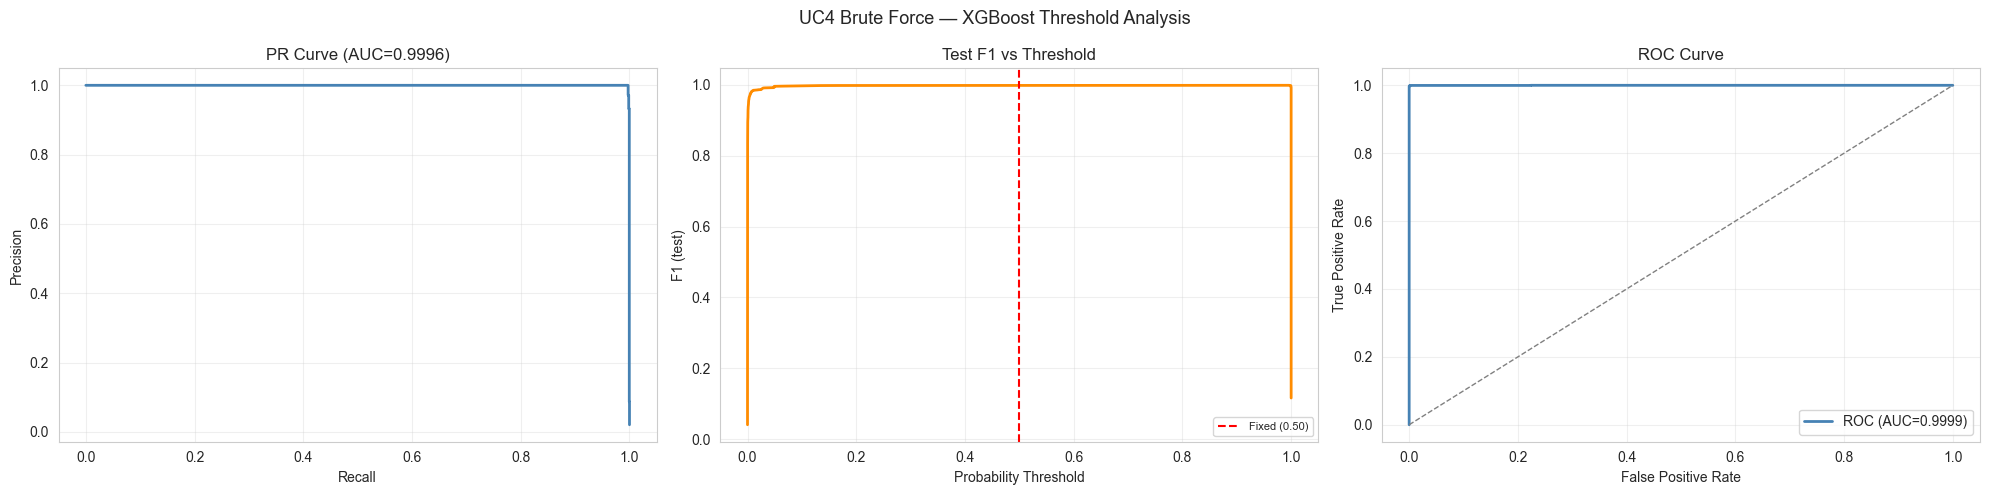

PR-AUC:  0.9996
ROC-AUC: 0.9999


In [9]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_proba)

# F1 across test thresholds (for the F1-vs-threshold panel only — NOT for selection)
f1_test_arr = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(recalls, precisions, lw=2, color='steelblue')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR Curve (AUC={pr_auc:.4f})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds_pr, f1_test_arr, lw=2, color='darkorange')
axes[1].axvline(threshold, color='red', ls='--',
                label=f'Fixed ({threshold:.2f})')
axes[1].set_xlabel('Probability Threshold'); axes[1].set_ylabel('F1 (test)')
axes[1].set_title('Test F1 vs Threshold')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(fpr_arr, tpr_arr, lw=2, color='steelblue',
             label=f'ROC (AUC={roc_auc:.4f})')
axes[2].plot([0, 1], [0, 1], ls='--', color='gray', lw=1)
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('UC4 Brute Force — XGBoost Threshold Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'PR-AUC:  {pr_auc:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')

## 9. Test Evaluation at the Fixed 0.5 Threshold

Apply the fixed 0.5 cutoff (Section 7) to the held-out test set. Because the
scores are bimodal, the result is the same across a wide band of thresholds —
shown in the operational sweep (Section 11).

── Threshold: 0.5000  (source: fixed_0.5) ──

              precision    recall  f1-score   support

      Benign     0.9999    1.0000    1.0000    131890
 Brute Force     0.9996    0.9975    0.9986      2804

    accuracy                         0.9999    134694
   macro avg     0.9998    0.9987    0.9993    134694
weighted avg     0.9999    0.9999    0.9999    134694

Test FPR: 0.0000  |  FP: 1  |  FN: 7


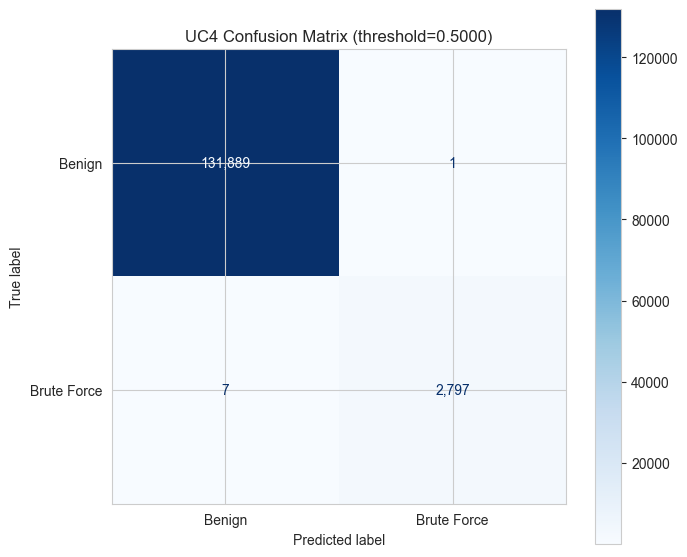

In [10]:
y_pred = (y_proba >= threshold).astype(int)

print(f'── Threshold: {threshold:.4f}  (source: {threshold_source}) ──\n')
print(classification_report(y_test, y_pred,
                            target_names=['Benign', 'Brute Force'],
                            digits=4, zero_division=0))

fp = ((y_test == 0) & (y_pred == 1)).sum()
fn = ((y_test == 1) & (y_pred == 0)).sum()
fpr_val = fp / max((y_test == 0).sum(), 1)
print(f'Test FPR: {fpr_val:.4f}  |  FP: {fp:,}  |  FN: {fn:,}')

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Benign', 'Brute Force'],
    cmap='Blues', ax=ax, values_format=',')
ax.set_title(f'UC4 Confusion Matrix (threshold={threshold:.4f})')
plt.tight_layout()
plt.show()

## 10. Operational Threshold Sweep

A DDoS/brute-force detector trades false negatives (missed attacks) against false
positives (benign flows flagged for throttling/blocking). The sweep shows metrics
across thresholds so an operator can confirm 0.5 sits on a flat, stable region —
the same check UC2 performs.

In [11]:
print(f'{"Threshold":>10s}  {"Precision":>10s}  {"Recall":>10s}  '
      f'{"F1":>10s}  {"FPR":>10s}  {"FP":>8s}  {"FN":>8s}')
print('-' * 72)

for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds = (y_proba >= t).astype(int)
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f = f1_score(y_test, preds, zero_division=0)
    fp_t = ((y_test == 0) & (preds == 1)).sum()
    fn_t = ((y_test == 1) & (preds == 0)).sum()
    fpr_t = fp_t / max((y_test == 0).sum(), 1)
    marker = '  ◄ policy' if abs(t - threshold) < 1e-9 else ''
    print(f'{t:10.4f}  {p:10.4f}  {r:10.4f}  {f:10.4f}  '
          f'{fpr_t:10.6f}  {fp_t:8,}  {fn_t:8,}{marker}')

 Threshold   Precision      Recall          F1         FPR        FP        FN
------------------------------------------------------------------------
    0.3000      0.9993      0.9975      0.9984    0.000015         2         7
    0.4000      0.9996      0.9975      0.9986    0.000008         1         7


    0.5000      0.9996      0.9975      0.9986    0.000008         1         7  ◄ policy
    0.6000      0.9996      0.9975      0.9986    0.000008         1         7
    0.7000      0.9996      0.9975      0.9986    0.000008         1         7


    0.8000      0.9996      0.9975      0.9986    0.000008         1         7
    0.9000      1.0000      0.9975      0.9988    0.000000         0         7


## 12. Feature Importance

Top features for distinguishing brute-force from benign traffic.
Compared qualitatively with UC2 to confirm the two models learn
different decision boundaries.

── Top 15 Features ──
    0.2345  Fwd Packet Length Min
    0.2119  min_seg_size_forward
    0.1073  Min Packet Length
    0.0899  Packet Length Variance
    0.0679  Init_Win_bytes_forward
    0.0502  Packet Length Std
    0.0491  Init_Win_bytes_backward
    0.0403  Fwd PSH Flags
    0.0333  Bwd Packet Length Min
    0.0178  Flow IAT Min
    0.0152  Flow Bytes/s
    0.0116  Fwd Packet Length Max
    0.0114  Bwd Packets/s
    0.0110  Total Backward Packets
    0.0087  Flow Packets/s


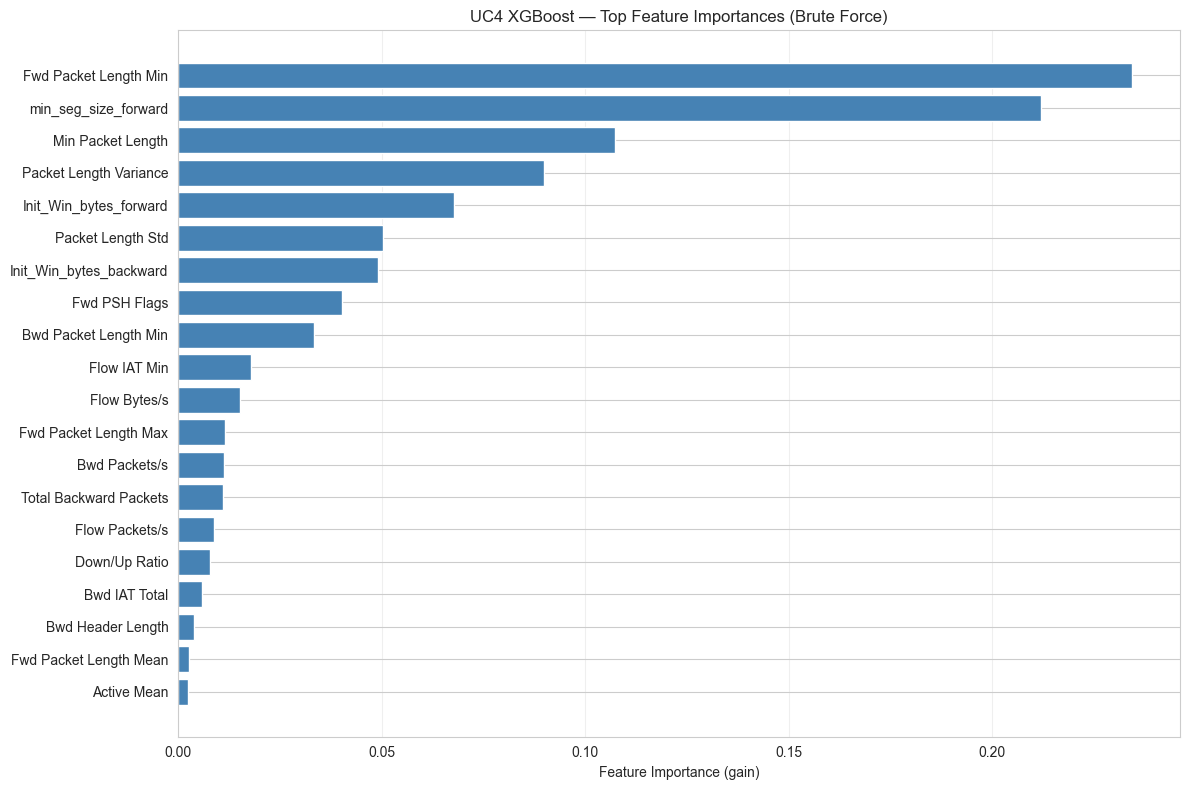

In [12]:
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances,
}).sort_values('importance', ascending=False)

print('── Top 15 Features ──')
for i, row in feat_imp.head(15).iterrows():
    print(f'  {row["importance"]:>8.4f}  {row["feature"]}')

fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(20, len(feat_imp))
top = feat_imp.head(top_n)
ax.barh(range(top_n), top['importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('UC4 XGBoost — Top Feature Importances (Brute Force)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 13. Score Distribution

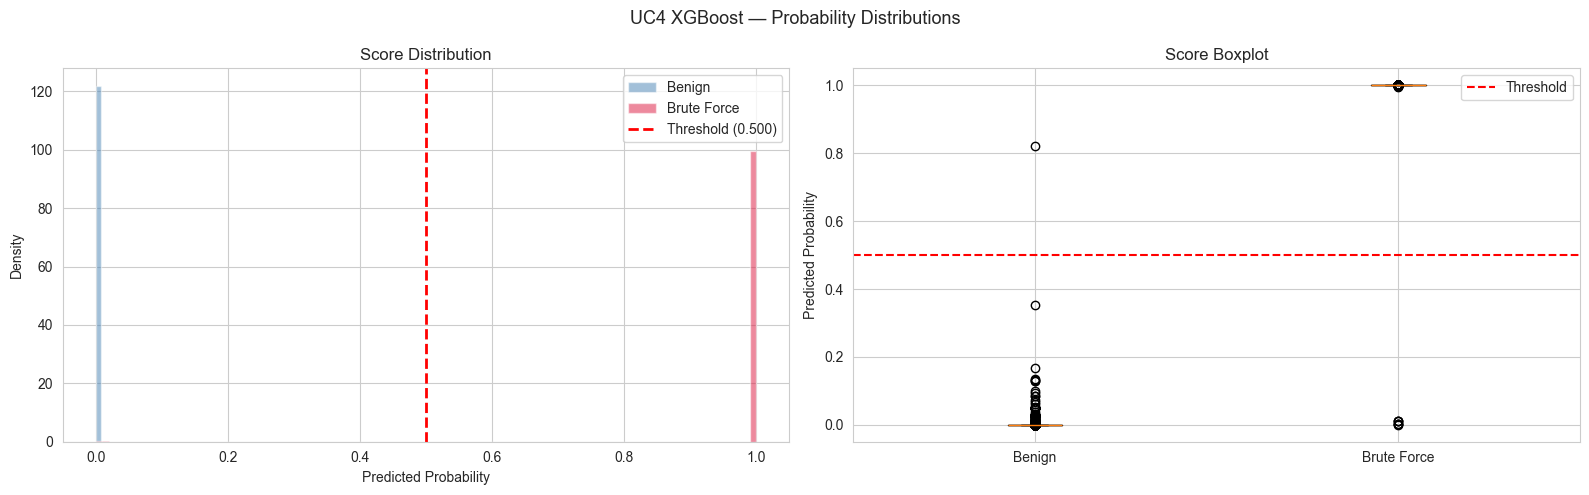

Benign median prob:   0.000001
Attack median prob:   0.999995
Separation (medians): 0.999993

Bimodal separation (benign~0, attack~1), same as UC2: this is why both use a fixed 0.5 threshold.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.hist(y_proba[y_test == 0], bins=100, alpha=0.5, density=True,
        label='Benign', color='steelblue')
ax.hist(y_proba[y_test == 1], bins=100, alpha=0.5, density=True,
        label='Brute Force', color='crimson')
ax.axvline(threshold, color='red', ls='--', lw=2,
           label=f'Threshold ({threshold:.3f})')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution')
ax.legend()

ax = axes[1]
ax.boxplot([y_proba[y_test == 0], y_proba[y_test == 1]],
           labels=['Benign', 'Brute Force'])
ax.axhline(threshold, color='red', ls='--', lw=1.5, label='Threshold')
ax.set_ylabel('Predicted Probability')
ax.set_title('Score Boxplot')
ax.legend()

plt.suptitle('UC4 XGBoost — Probability Distributions', fontsize=13)
plt.tight_layout()
plt.show()

ben_median = np.median(y_proba[y_test == 0])
atk_median = np.median(y_proba[y_test == 1])
print(f'Benign median prob:   {ben_median:.6f}')
print(f'Attack median prob:   {atk_median:.6f}')
print(f'Separation (medians): {abs(atk_median - ben_median):.6f}')
print('\nBimodal separation (benign~0, attack~1), same as UC2: this is why both '
      'use a fixed 0.5 threshold.')

## 14. False Positive Analysis

Profile benign flows incorrectly flagged as brute-force. Identifies which
features drive false alarms at the 0.5 operating point.

In [14]:
fp_mask = (y_test == 0) & (y_pred == 1)
n_fp = fp_mask.sum()
print(f'False positives: {n_fp:,} / {(y_test == 0).sum():,} benign flows')

if 0 < n_fp < len(df_test):
    fp_feats  = df_test.loc[fp_mask, feature_cols]
    ben_feats = df_test.loc[y_test == 0, feature_cols]
    atk_feats = df_test.loc[y_test == 1, feature_cols]

    ben_mean = ben_feats.mean()
    ben_std  = ben_feats.std().replace(0, 1e-9)
    fp_z = ((fp_feats.mean() - ben_mean) / ben_std).abs().sort_values(ascending=False)

    print('\nTop features driving FPs (z-score vs benign baseline):')
    for feat, z in fp_z.head(10).items():
        print(f'  {feat:40s}  z={z:>6.2f}  '
              f'(FP={fp_feats[feat].mean():>12.2f}, '
              f'benign={ben_mean[feat]:>12.2f}, '
              f'attack={atk_feats[feat].mean():>12.2f})')

    fp_probs = y_proba[fp_mask]
    print(f'\nFP probability range:  [{fp_probs.min():.4f}, {fp_probs.max():.4f}]')
    print(f'FP probability median: {np.median(fp_probs):.4f}')
    print(f'FPs near threshold (prob < threshold+0.1): '
          f'{(fp_probs < threshold + 0.1).sum()} / {n_fp}')
elif n_fp == 0:
    print('No false positives at the 0.5 threshold.')

False positives: 1 / 131,890 benign flows



Top features driving FPs (z-score vs benign baseline):
  Bwd Packets/s                             z=  2.43  (FP=    90909.09, benign=     5951.29, attack=     1519.33)
  ACK Flag Count                            z=  1.58  (FP=        1.00, benign=        0.29, attack=        0.50)
  Protocol                                  z=  0.93  (FP=        6.00, benign=       11.08, attack=        6.00)
  min_seg_size_forward                      z=  0.92  (FP=       32.00, benign=       26.13, attack=       32.00)
  Min Packet Length                         z=  0.83  (FP=        0.00, benign=       20.53, attack=        0.00)
  Bwd Packet Length Min                     z=  0.72  (FP=        0.00, benign=       51.09, attack=        0.00)
  Down/Up Ratio                             z=  0.59  (FP=        1.00, benign=        0.69, attack=        0.50)
  Flow Packets/s                            z=  0.56  (FP=   181818.18, benign=    57060.78, attack=    87319.96)
  Fwd Packet Length Min         

## 15. False Negative Analysis

Profile attack flows the model missed. Reveals the limits of per-flow supervised
detection for brute force.

In [15]:
fn_mask = (y_test == 1) & (y_pred == 0)
n_fn = fn_mask.sum()
print(f'False negatives: {n_fn:,} / {(y_test == 1).sum():,} attack flows')

if 0 < n_fn < len(df_test):
    fn_feats  = df_test.loc[fn_mask, feature_cols]
    atk_feats = df_test.loc[y_test == 1, feature_cols]
    ben_feats = df_test.loc[y_test == 0, feature_cols]

    atk_mean = atk_feats.mean()
    ben_mean = ben_feats.mean()
    fn_mean  = fn_feats.mean()

    fn_to_ben = np.sqrt(((fn_mean - ben_mean) ** 2).sum())
    fn_to_atk = np.sqrt(((fn_mean - atk_mean) ** 2).sum())

    print(f'\nFN centroid distance to benign:  {fn_to_ben:.2f}')
    print(f'FN centroid distance to attack:  {fn_to_atk:.2f}')
    if fn_to_ben < fn_to_atk:
        print('→ FN flows are closer to benign — they look like benign traffic.')
    else:
        print('→ FN flows are closer to attack — borderline cases near threshold.')

    fn_probs = y_proba[fn_mask]
    print(f'\nFN probability range:  [{fn_probs.min():.4f}, {fn_probs.max():.4f}]')
    print(f'FN probability median: {np.median(fn_probs):.4f}')
    print(f'FNs near threshold (prob > threshold-0.1): '
          f'{(fn_probs > threshold - 0.1).sum()} / {n_fn}')
elif n_fn == 0:
    print('No false negatives at the 0.5 threshold.')

False negatives: 7 / 2,804 attack flows

FN centroid distance to benign:  15488243.57
FN centroid distance to attack:  5356899.72
→ FN flows are closer to attack — borderline cases near threshold.

FN probability range:  [0.0000, 0.0120]
FN probability median: 0.0031
FNs near threshold (prob > threshold-0.1): 0 / 7


## 16. Cross-UC Evaluation

Test whether UC2's DDoS model catches brute-force traffic and vice versa.
Validates that the two models learn genuinely different decision boundaries,
justifying separate models in the Detection service.

**If the UC2 artifact is unavailable**, this section skips gracefully.

In [16]:
if os.path.exists(UC2_ARTIFACT):
    print('── Cross-UC: UC2 (DDoS) predictions on UC4 test set (Brute Force) ──\n')
    uc2_art    = joblib.load(UC2_ARTIFACT)
    uc2_scaler = uc2_art['scaler']
    uc2_model  = uc2_art['model']
    uc2_thresh = uc2_art['threshold']

    uc2_proba = uc2_model.predict_proba(uc2_scaler.transform(X_test))[:, 1]
    uc2_pred  = (uc2_proba >= uc2_thresh).astype(int)

    attack_mask = (y_test == 1)
    uc2_catches = (uc2_pred == 1) & attack_mask
    uc4_catches = (y_pred  == 1) & attack_mask

    n_atk     = attack_mask.sum()
    n_uc2     = uc2_catches.sum()
    n_uc4     = uc4_catches.sum()
    n_both    = (uc2_catches & uc4_catches).sum()
    n_uc2only = (uc2_catches & ~uc4_catches).sum()
    n_uc4only = (~uc2_catches & uc4_catches).sum()
    n_missed  = (attack_mask & ~uc2_catches & ~uc4_catches).sum()

    print(f'Total BF flows in test:       {n_atk:,}')
    print(f'UC2 catches:                  {n_uc2:,}   (recall {n_uc2/max(n_atk,1):.4f})')
    print(f'UC4 catches:                  {n_uc4:,}   (recall {n_uc4/max(n_atk,1):.4f})')
    print(f'Union (either catches):       {(uc2_catches|uc4_catches).sum():,}')
    print(f'  both models agree:          {n_both:,}')
    print(f'  UC2 only (UC4 misses):      {n_uc2only:,}')
    print(f'  UC4 only (UC2 misses):      {n_uc4only:,}   ← UC4 marginal value')
    print(f'  neither catches:            {n_missed:,}')

    benign_mask = (y_test == 0)
    fp_uc2 = ((uc2_pred == 1) & benign_mask).sum()
    fp_uc4 = ((y_pred  == 1) & benign_mask).sum()
    print(f'\nBenign FPs  — UC2: {fp_uc2:,}   UC4: {fp_uc4:,}')
else:
    print(f'UC2 artifact not found at {UC2_ARTIFACT} — skipping marginal-catch analysis.')

── Cross-UC: UC2 (DDoS) predictions on UC4 test set (Brute Force) ──



Total BF flows in test:       2,804
UC2 catches:                  0   (recall 0.0000)
UC4 catches:                  2,797   (recall 0.9975)
Union (either catches):       2,797
  both models agree:          0
  UC2 only (UC4 misses):      0
  UC4 only (UC2 misses):      2,797   ← UC4 marginal value
  neither catches:            7

Benign FPs  — UC2: 0   UC4: 1


In [17]:
UC2_TEST_CSV = os.path.join('../ddos/data/', 'test.csv')

if os.path.exists(UC2_ARTIFACT) and os.path.exists(UC2_TEST_CSV):
    print('── Cross-UC: UC4 (BF model) on UC2 test set (DDoS) ──\n')
    df_uc2_test = pd.read_csv(UC2_TEST_CSV)

    X_uc2_test = scaler.transform(df_uc2_test[feature_cols].values)
    uc4_on_ddos_proba = model.predict_proba(X_uc2_test)[:, 1]
    uc4_on_ddos_pred  = (uc4_on_ddos_proba >= threshold).astype(int)
    y_uc2_test = df_uc2_test['label'].values

    print(classification_report(y_uc2_test, uc4_on_ddos_pred,
                                target_names=['Benign', 'DDoS'],
                                digits=4, zero_division=0))

    uc4_on_ddos_f1  = f1_score(y_uc2_test, uc4_on_ddos_pred, zero_division=0)
    uc4_on_ddos_rec = recall_score(y_uc2_test, uc4_on_ddos_pred, zero_division=0)

    print(f'UC4 (BF model) on DDoS data — Recall: {uc4_on_ddos_rec:.4f}, F1: {uc4_on_ddos_f1:.4f}')
    print()
    if uc4_on_ddos_rec < 0.5:
        print('→ UC4 does NOT generalize to DDoS — confirms different decision boundaries.')
    else:
        print('→ UC4 partially detects DDoS — some feature overlap between attack types.')
else:
    print('UC2 test data or artifact not available — skipping reverse cross-evaluation.')

── Cross-UC: UC4 (BF model) on UC2 test set (DDoS) ──



              precision    recall  f1-score   support

      Benign     0.5533    1.0000    0.7124     41248
        DDoS     0.0000    0.0000    0.0000     33296

    accuracy                         0.5533     74544
   macro avg     0.2767    0.5000    0.3562     74544
weighted avg     0.3062    0.5533    0.3942     74544

UC4 (BF model) on DDoS data — Recall: 0.0000, F1: 0.0000

→ UC4 does NOT generalize to DDoS — confirms different decision boundaries.


## 17. Per-Attack-Type Breakdown

Evaluate FTP-Patator and SSH-Patator separately. SSH-Patator is expected to be
absent from the test set: on CICIDS2017 Tuesday the two campaigns are sequential
and non-overlapping (SSH 02:09–03:11, FTP 09:17–10:30), so no temporal cut puts
both in train and test. The 70/30 boundary keeps SSH entirely in training and
evaluates on FTP — same repeated-auth mechanism, different protocol. This is a
documented, expected limitation, not a defect.

In [18]:
if 'attack_type' in df_test.columns:
    print('── Per-Attack-Type Metrics ──\n')
    for attack_label in ['FTP-Patator', 'SSH-Patator']:
        mask = (df_test['attack_type'] == attack_label).values
        n_type = mask.sum()
        if n_type == 0:
            print(f'{attack_label:20s}  Not present in test set (expected for SSH-Patator)')
            continue
        type_pred = y_pred[mask]
        type_true = y_test[mask]
        rec  = recall_score(type_true, type_pred, zero_division=0)
        prec = precision_score(type_true, type_pred, zero_division=0)
        f1v  = f1_score(type_true, type_pred, zero_division=0)
        n_detected = type_pred.sum()
        print(f'{attack_label:20s}  {n_detected:>6,} / {n_type:>6,} detected  '
              f'(recall: {rec:.4f}, precision: {prec:.4f}, F1: {f1v:.4f})')

    print(f'\n{"Overall":20s}  recall: {recall_score(y_test, y_pred, zero_division=0):.4f}')
else:
    print('No attack_type column in test CSV — re-run the data-prep notebook')
    print('with attack_type included in export_cols.')
    print(f'Overall attack recall: {recall_score(y_test, y_pred, zero_division=0):.4f}')

── Per-Attack-Type Metrics ──

FTP-Patator            2,797 /  2,804 detected  (recall: 0.9975, precision: 1.0000, F1: 0.9988)
SSH-Patator           Not present in test set (expected for SSH-Patator)

Overall               recall: 0.9975


## 18. Model Persistence

Save as a single artifact bundle, matching UC2's format. The Detection
microservice loads both `ddos_xgboost.pkl` and `brute_force_xgboost.pkl`
and runs both on every incoming flow. The `threshold_source` field records
provenance — `fixed_0.5`, identical to UC2.

In [19]:
artifact = {
    'model':          model,
    'scaler':         scaler,
    'threshold':      float(threshold),
    'feature_cols':   feature_cols,
    'params': {
        'n_estimators':     model.n_estimators,
        'max_depth':        model.max_depth,
        'learning_rate':    model.learning_rate,
        'scale_pos_weight': float(spw),
        'seed':             SEED,
        'best_iteration':   int(model.best_iteration),
    },
    'metrics': {
        'threshold':                   float(threshold),
        'threshold_source':            threshold_source,
        # Validation (selection) reporting
        'val_size':                    int(len(y_val)),
        'val_ap':                      float(val_ap),
        'val_f1_at_threshold':         float(val_f1_at_05),
        # Test reporting (at the frozen threshold)
        'test_size':                   int(len(y_test)),
        'test_roc_auc':                float(roc_auc),
        'test_pr_auc':                 float(pr_auc),
        'test_f1_at_threshold':        float(f1_score(y_test, y_pred, zero_division=0)),
        'test_precision_at_threshold': float(precision_score(y_test, y_pred, zero_division=0)),
        'test_recall_at_threshold':    float(recall_score(y_test, y_pred, zero_division=0)),
        'test_fpr_at_threshold':       float(fpr_val),
        'best_iteration':              int(model.best_iteration),
    },
    'label_map': {0: 'BENIGN', 1: 'BruteForce'},
}

joblib.dump(artifact, ARTIFACT_OUT, compress=3)
size_mb = os.path.getsize(ARTIFACT_OUT) / (1024 * 1024)
print(f'Artifact saved: {ARTIFACT_OUT}  ({size_mb:.2f} MB)')
print(f'Contents: {list(artifact.keys())}')
print(f'Threshold source: {threshold_source}')

Artifact saved: ./models/brute_force_xgboost.pkl  (0.09 MB)
Contents: ['model', 'scaler', 'threshold', 'feature_cols', 'params', 'metrics', 'label_map']
Threshold source: fixed_0.5


## 19. Artifact Verification

In [20]:
art = joblib.load(ARTIFACT_OUT)

X_verify = art['scaler'].transform(df_test[art['feature_cols']].values)
verify_proba = art['model'].predict_proba(X_verify)[:, 1]
verify_pred  = (verify_proba >= art['threshold']).astype(int)

assert np.allclose(verify_proba, y_proba, atol=1e-6), 'Probability mismatch!'
assert np.array_equal(verify_pred, y_pred), 'Prediction mismatch!'

print('Artifact verification passed.')
print(f'  Model:            {type(art["model"]).__name__}')
print(f'  Features:         {len(art["feature_cols"])}')
print(f'  Threshold:        {art["threshold"]:.6f}  (source: {art["metrics"]["threshold_source"]})')
print(f'  Test F1:          {art["metrics"]["test_f1_at_threshold"]:.4f}')
print(f'  Test Recall:      {art["metrics"]["test_recall_at_threshold"]:.4f}')
print(f'  Test FPR:         {art["metrics"]["test_fpr_at_threshold"]:.4f}')
print(f'  Test ROC-AUC:     {art["metrics"]["test_roc_auc"]:.4f}')

Artifact verification passed.
  Model:            XGBClassifier
  Features:         43
  Threshold:        0.500000  (source: fixed_0.5)
  Test F1:          0.9986
  Test Recall:      0.9975
  Test FPR:         0.0000
  Test ROC-AUC:     0.9999


## 20. Inference Helper

Reusable function for the Detection microservice. In production the artifact is
loaded **once at service startup**, not per flow — the `_load` cache below
mirrors that. The consumer runs this alongside `predict_uc2()` on every flow
from `log.normalized.flow`.

In [21]:
_UC4_CACHE = {}

def _load_uc4(artifact_path):
    if artifact_path not in _UC4_CACHE:
        _UC4_CACHE[artifact_path] = joblib.load(artifact_path)
    return _UC4_CACHE[artifact_path]


def predict_uc4(flow_features: dict, artifact_path: str = None) -> dict:
    """
    Run UC4 Brute Force inference on a single flow record.

    Parameters
    ----------
    flow_features : dict
        Feature values for one flow. Must contain all keys from feature_cols.
    artifact_path : str, optional
        Path to the saved .pkl artifact. Defaults to ARTIFACT_OUT.

    Returns
    -------
    dict with keys: 'prediction' (0/1), 'probability', 'threshold', 'is_attack'.
    """
    if artifact_path is None:
        artifact_path = ARTIFACT_OUT

    art = _load_uc4(artifact_path)
    features = art['feature_cols']
    threshold_val = art['threshold']

    df = pd.DataFrame([flow_features])
    X = art['scaler'].transform(df[features].values)
    prob = float(art['model'].predict_proba(X)[0, 1])
    pred = int(prob >= threshold_val)

    return {
        'prediction':  pred,
        'probability': prob,
        'threshold':   threshold_val,
        'is_attack':   bool(pred == 1),
    }


# Verification — predict on a test sample
sample_flow = df_test.iloc[0][feature_cols].to_dict()
result = predict_uc4(sample_flow)
print('Inference helper verified.')
print(f'Sample prediction: {result["prediction"]} '
      f'(prob={result["probability"]:.4f}, threshold={result["threshold"]:.4f})')

Inference helper verified.
Sample prediction: 0 (prob=0.0000, threshold=0.5000)


## 21. Summary

In [22]:
print('=' * 70)
print('UC4 BRUTE FORCE DETECTION — XGBOOST TRAINING SUMMARY')
print('=' * 70)
print(f'Dataset:          CICIDS2017 (Monday benign + Tuesday Brute Force)')
print(f'Model:            XGBoost (supervised binary classification)')
print(f'Features:         {len(feature_cols)} (shared with UC2)')
print(f'Train fold:       {len(y_tr):>10,}  (pos_rate={y_tr.mean():.4f})')
print(f'Validation slice: {len(y_val):>10,}  (stratified; early stopping + threshold)')
print(f'Test:             {len(y_test):>10,}  (pos_rate={y_test.mean():.4f})')
print(f'Best iteration:   {model.best_iteration}')
print()
print(f'── Threshold policy ──')
print(f'Source:           {threshold_source}  (standard cutoff; same as UC2)')
print(f'Value:            {threshold:.4f}')
print(f'Same as UC2:      Both use fixed_0.5, justified by bimodal score')
print(f'                  separation (benign~0, attack~1) shown in Section 13.')
print()
print(f'── Test performance @ fixed 0.5 threshold ──')
print(f'ROC-AUC:   {roc_auc:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}')
print(f'F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'FPR:       {fpr_val:.4f}')
print()
print(f'── Artifact ──')
print(f'{ARTIFACT_OUT}')
print()
print(f'── Detection Service Integration ──')
print(f'Flow arrives → extract features → UC2 predict (DDoS?)')
print(f'                                → UC4 predict (Brute Force?)')
print(f'                                → publish both results to detection.results')
print('=' * 70)

UC4 BRUTE FORCE DETECTION — XGBOOST TRAINING SUMMARY
Dataset:          CICIDS2017 (Monday benign + Tuesday Brute Force)
Model:            XGBoost (supervised binary classification)
Features:         43 (shared with UC2)
Train fold:          714,963  (pos_rate=0.0131)
Validation slice:    126,170  (stratified; early stopping + threshold)
Test:                134,694  (pos_rate=0.0208)
Best iteration:   221

── Threshold policy ──
Source:           fixed_0.5  (standard cutoff; same as UC2)
Value:            0.5000
Same as UC2:      Both use fixed_0.5, justified by bimodal score
                  separation (benign~0, attack~1) shown in Section 13.

── Test performance @ fixed 0.5 threshold ──
ROC-AUC:   0.9999
PR-AUC:    0.9996
F1:        0.9986
Precision: 0.9996
Recall:    0.9975
FPR:       0.0000

── Artifact ──
./models/brute_force_xgboost.pkl

── Detection Service Integration ──
Flow arrives → extract features → UC2 predict (DDoS?)
                                → UC4 predict (Brute